In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [3]:
image_cut = image[52:172, 0:1890]
image_error_cut = image_error[52:172, 0:1890]

Text(0.5, 0, 'wavelength')

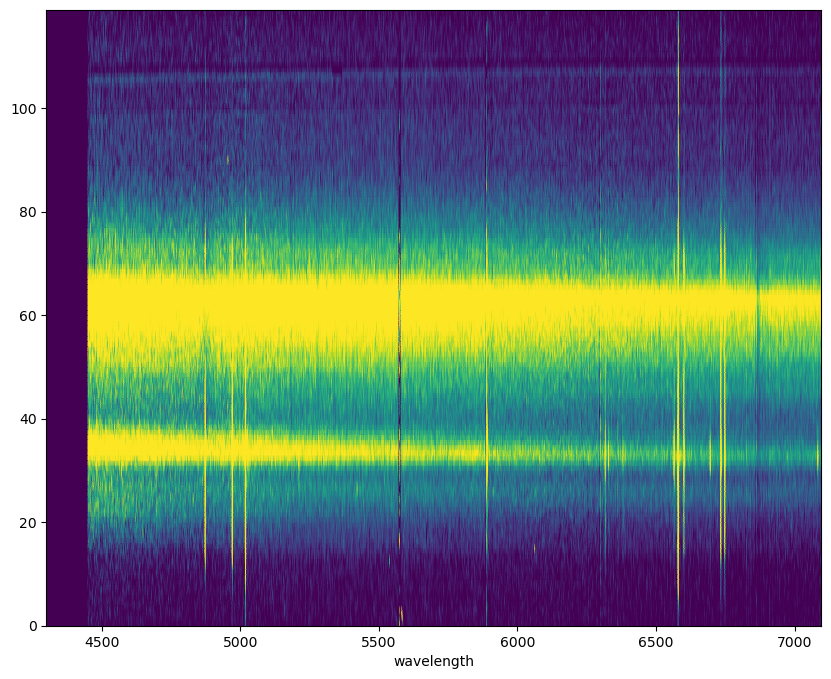

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.00309
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049\MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/PSF/Real_seeing_MGC+01-32-049.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.17687737 1.30227052 1.17372402 1.15290603 1.31110318 1.18212766]


In [6]:
l_NII

6603.34147

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

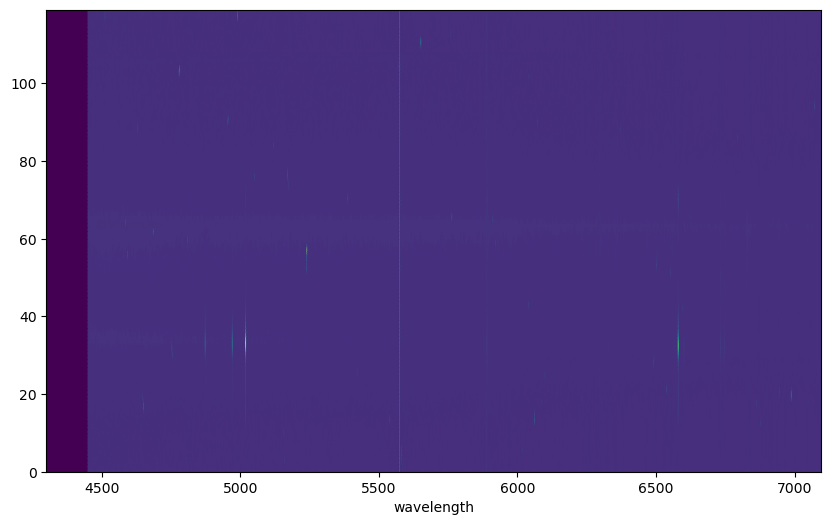

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[52:172, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

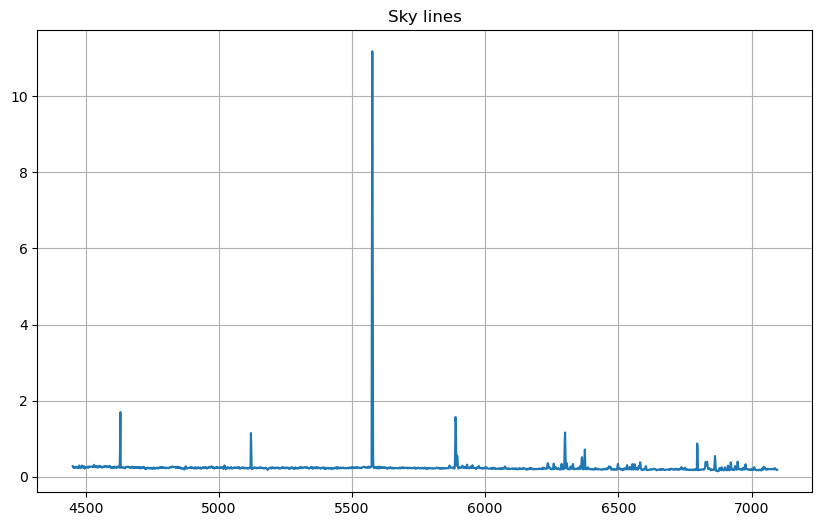

In [8]:
mask_sky = (y > 80)*(y < 90)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

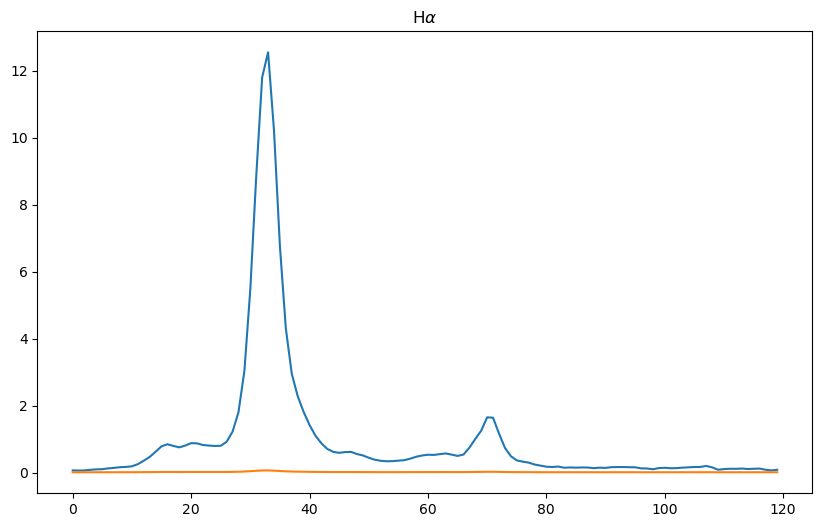

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [32]:
n_component = 4

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])# +
        #sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 5),
    (0.1, 10),
    (15, 16),
    
    (0, 20),
    (0, 5),
    (0.1, 10),
    (20, 21),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (30, 35),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (69, 71),
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [28]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2806.940893557491
differential_evolution step 2: f(x)= 2806.940893557491
differential_evolution step 3: f(x)= 799.0335256705314
differential_evolution step 4: f(x)= 799.0335256705314
differential_evolution step 5: f(x)= 439.79497403870084
differential_evolution step 6: f(x)= 439.79497403870084
differential_evolution step 7: f(x)= 439.79497403870084
differential_evolution step 8: f(x)= 439.79497403870084
differential_evolution step 9: f(x)= 439.79497403870084
differential_evolution step 10: f(x)= 439.79497403870084
differential_evolution step 11: f(x)= 439.79497403870084
differential_evolution step 12: f(x)= 439.79497403870084
differential_evolution step 13: f(x)= 439.79497403870084
differential_evolution step 14: f(x)= 439.79497403870084
differential_evolution step 15: f(x)= 439.79497403870084
differential_evolution step 16: f(x)= 439.79497403870084
differential_evolution step 17: f(x)= 439.79497403870084
differential_evolution step 18: f(x)= 439.79

Sérsic 1: I_e=0.2798, r_e=3.0779, n=0.6585, x_0=15.5912
Sérsic 2: I_e=0.4054, r_e=1.2798, n=0.1154, x_0=20.4395
Sérsic 3: I_e=1.1067, r_e=7.1141, n=1.8642, x_0=32.7376
Sérsic 4: I_e=0.0351, r_e=49.9863, n=2.4353, x_0=70.0490


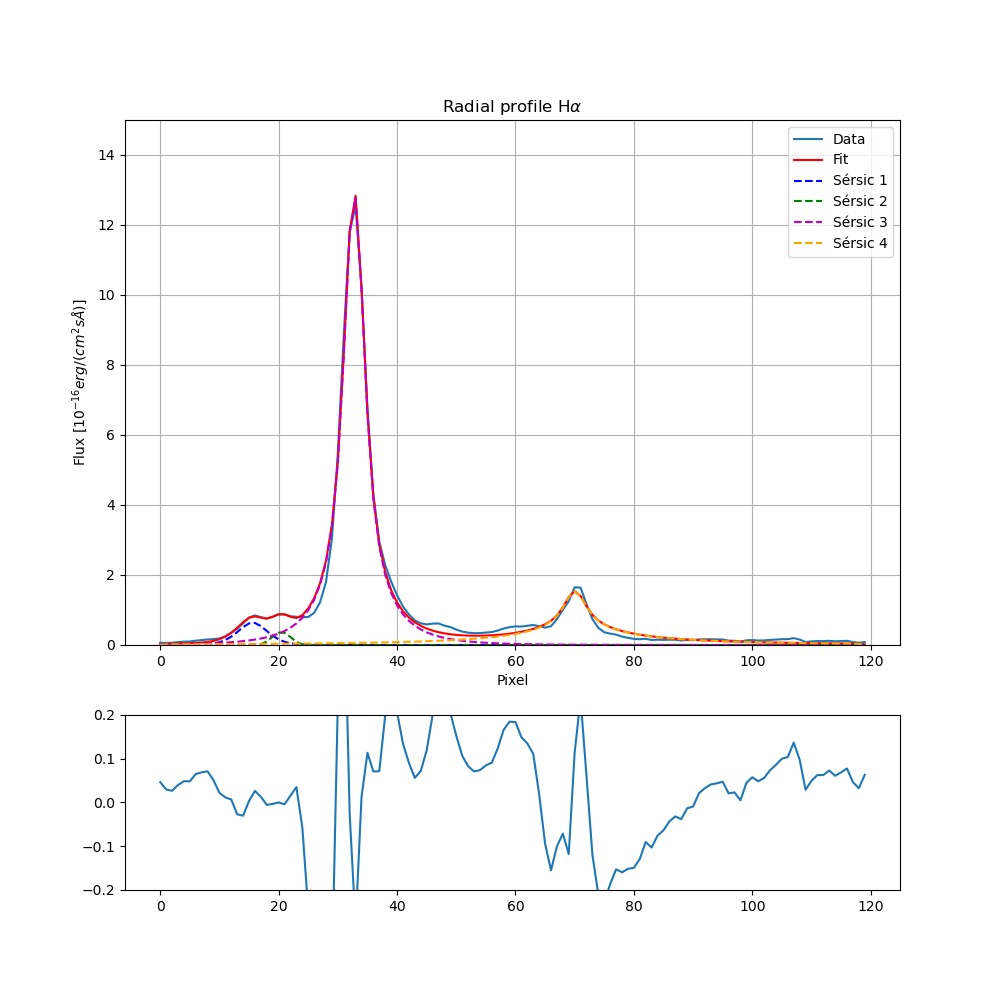

In [33]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [37]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA) #, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2784, r_e=2.3475, n=0.5912, x_0=15.7128
Sérsic 2: I_e=0.3255, r_e=1.2793, n=0.0687, x_0=20.4228
Sérsic 3: I_e=0.2949, r_e=15.6642, n=3.0052, x_0=33.0262
Sérsic 4: I_e=0.0062, r_e=172.7344, n=3.5431, x_0=70.0193
[2.43714819e-01 9.28872907e-01 7.10690263e-01 9.06494489e-01
 1.23842944e+02 1.35661927e+02 3.33071074e+01 1.00915384e+00
 1.19904255e-01 3.91510926e+00 4.55851290e-01 1.07584326e-01
 1.22879736e-02 2.54728877e+02 1.70263147e+00 7.90223600e-04]
12.945795843299551


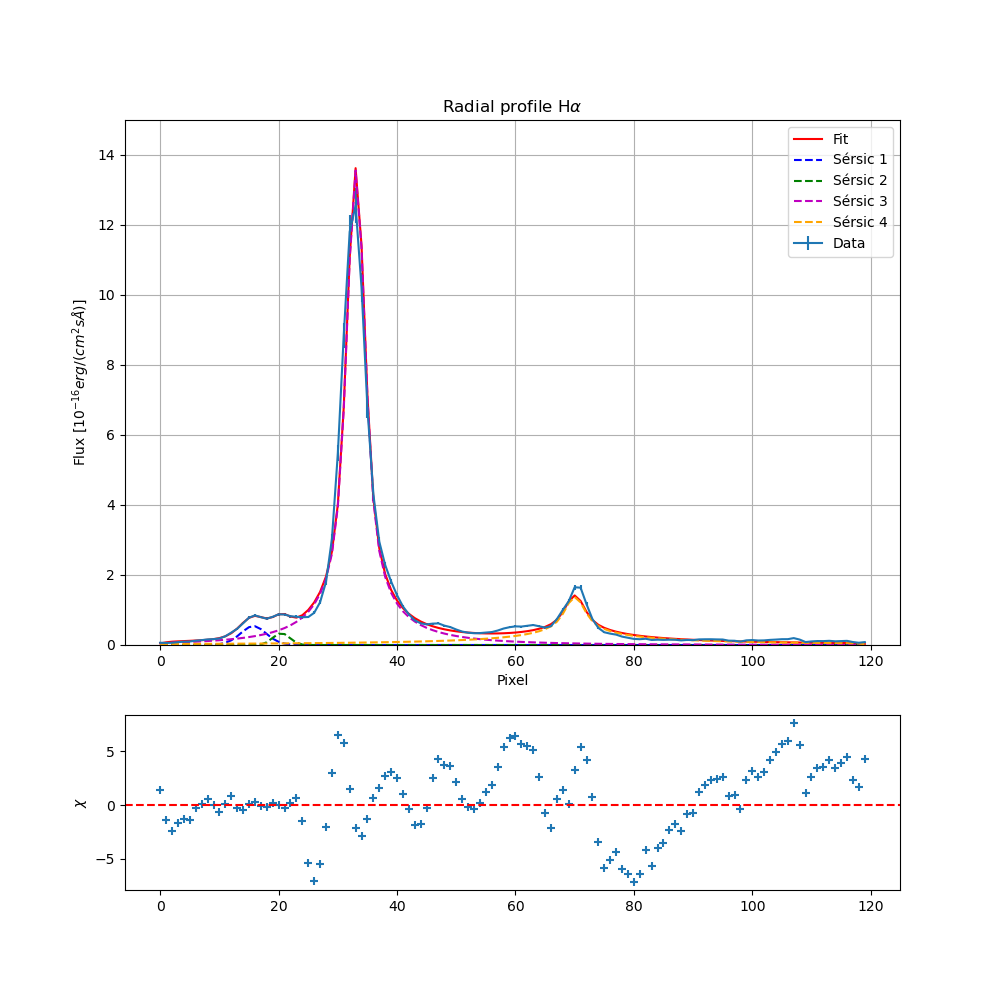

In [38]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [79]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 5),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 5),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

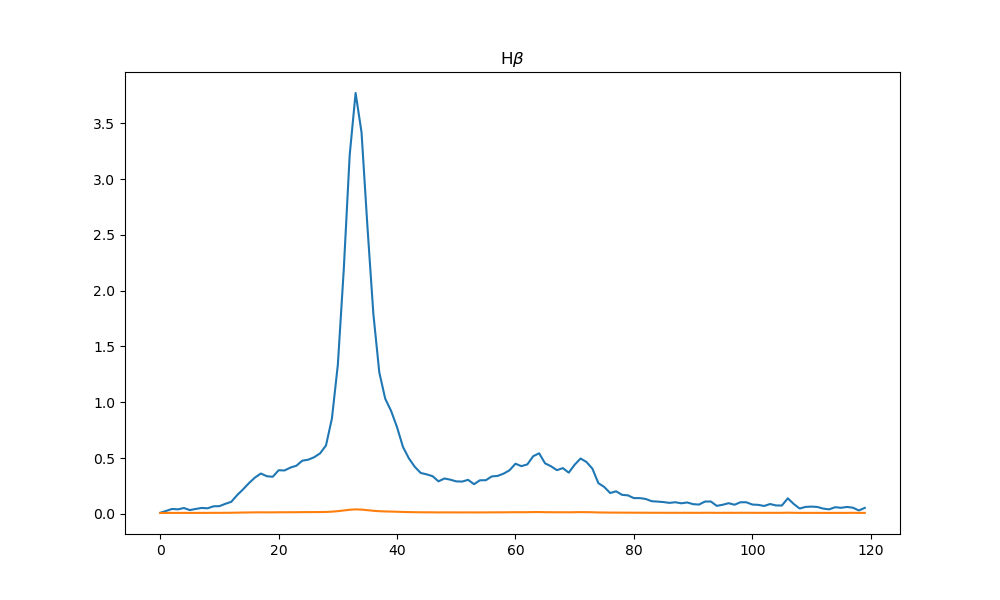

In [80]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 120, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [81]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1672.2319389900133
differential_evolution step 2: f(x)= 1672.2319389900133
differential_evolution step 3: f(x)= 112.41309179426841
differential_evolution step 4: f(x)= 112.41309179426841
differential_evolution step 5: f(x)= 66.3082451834195
differential_evolution step 6: f(x)= 66.3082451834195
differential_evolution step 7: f(x)= 66.3082451834195
differential_evolution step 8: f(x)= 66.3082451834195
differential_evolution step 9: f(x)= 49.99612188280047
differential_evolution step 10: f(x)= 49.99612188280047
differential_evolution step 11: f(x)= 49.99612188280047
differential_evolution step 12: f(x)= 49.99612188280047
differential_evolution step 13: f(x)= 49.99612188280047
differential_evolution step 14: f(x)= 18.553174852651395
differential_evolution step 15: f(x)= 18.553174852651395
differential_evolution step 16: f(x)= 18.553174852651395
differential_evolution step 17: f(x)= 15.38007572966976
differential_evolution step 18: f(x)= 12.4850160924669

Sérsic 1: I_e=0.1477, r_e=1.4829, n=0.3230, x_0=16.3173
Sérsic 2: I_e=0.1115, r_e=1.9859, n=0.1008, x_0=21.2622
Sérsic 3: I_e=0.0663, r_e=27.4115, n=2.9777, x_0=33.2289
Sérsic 4: I_e=0.0838, r_e=25.3062, n=1.0087, x_0=68.6303


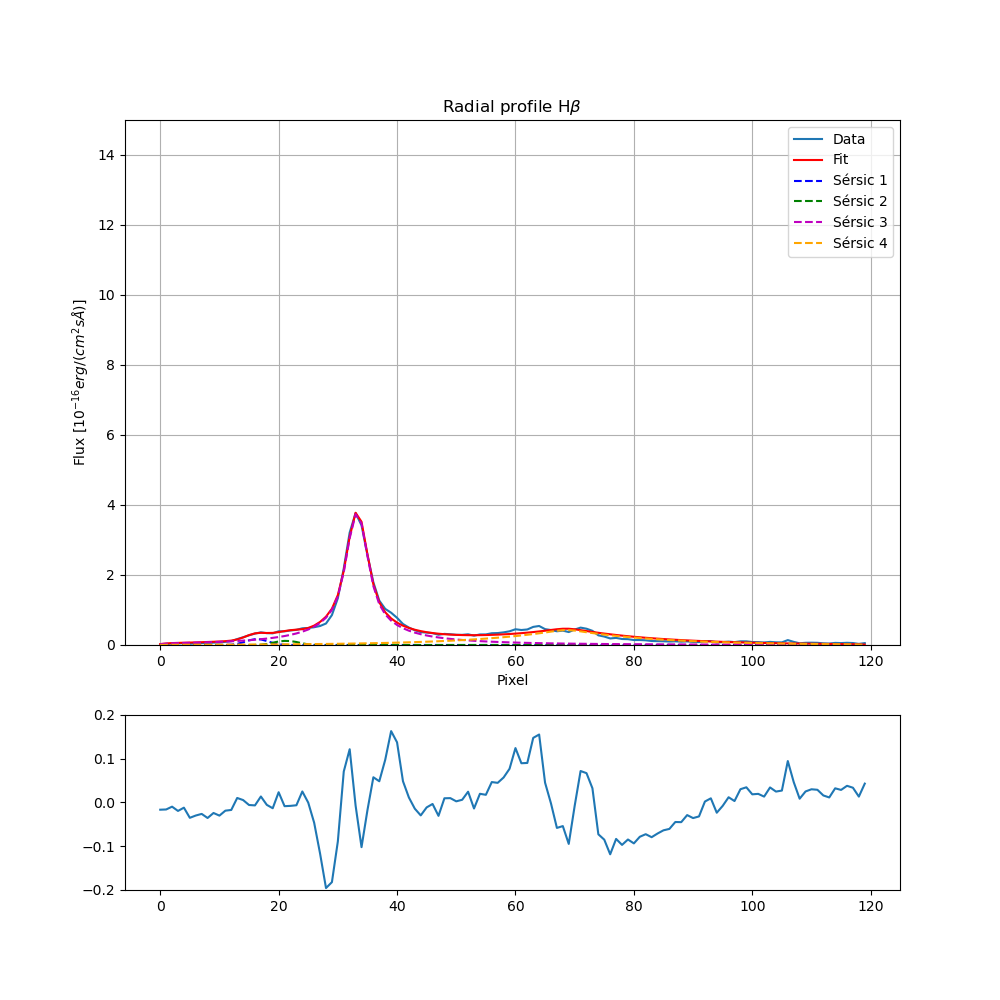

In [82]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [83]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1795, r_e=1.3758, n=0.1670, x_0=16.1225
Sérsic 2: I_e=0.1210, r_e=2.2729, n=0.1260, x_0=21.1687
Sérsic 3: I_e=0.0760, r_e=24.2648, n=2.8578, x_0=33.4771
Sérsic 4: I_e=0.0503, r_e=35.0738, n=1.3052, x_0=68.6303
[4.17155746e-01 7.20485860e+00 5.03052156e+00 3.39560072e+00
 2.24773134e-01 1.45363493e+01 2.67578990e+00 4.90286843e+00
 6.12124467e-02 1.23989044e+01 9.73036676e-01 1.14687742e-03
 1.49373547e-02 8.88051700e+00 2.01778167e-01 5.73262977e-01]
6.7194493657445316


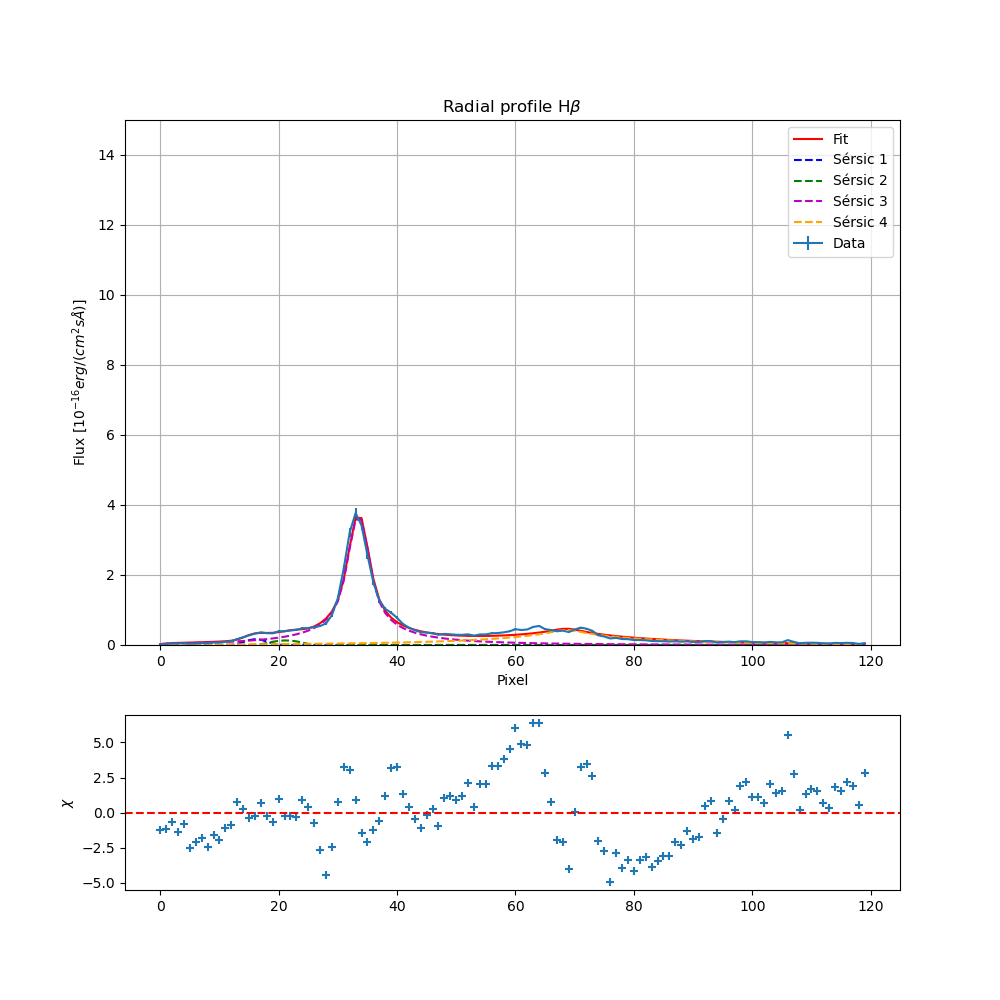

In [84]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

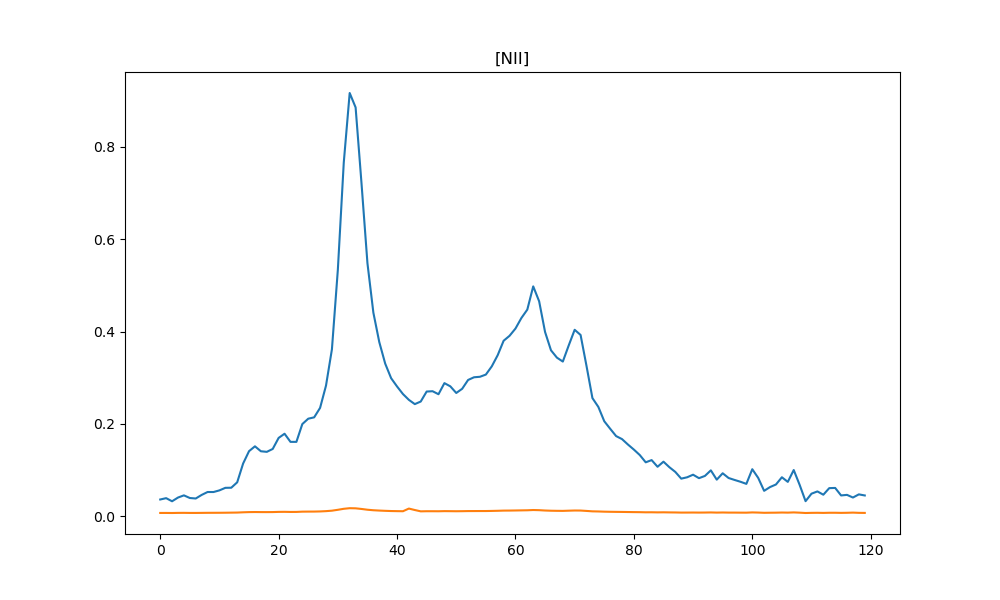

In [85]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [86]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2985.0709820193574
differential_evolution step 2: f(x)= 2985.0709820193574
differential_evolution step 3: f(x)= 997.6531488803812
differential_evolution step 4: f(x)= 838.050804094533
differential_evolution step 5: f(x)= 838.050804094533
differential_evolution step 6: f(x)= 759.1787296635625
differential_evolution step 7: f(x)= 759.1787296635625
differential_evolution step 8: f(x)= 282.1654452590843
differential_evolution step 9: f(x)= 282.1654452590843
differential_evolution step 10: f(x)= 165.59122673962543
differential_evolution step 11: f(x)= 165.59122673962543
differential_evolution step 12: f(x)= 125.70073629799313
differential_evolution step 13: f(x)= 118.05146308506849
differential_evolution step 14: f(x)= 24.457384218042424
differential_evolution step 15: f(x)= 24.457384218042424
differential_evolution step 16: f(x)= 24.457384218042424
differential_evolution step 17: f(x)= 24.457384218042424
differential_evolution step 18: f(x)= 24.45738421

Sérsic 1: I_e=0.8047, r_e=0.0467, n=0.5098, x_0=15.6463
Sérsic 2: I_e=0.0399, r_e=0.2016, n=1.8756, x_0=19.7978
Sérsic 3: I_e=0.0166, r_e=49.9996, n=2.6001, x_0=32.5249
Sérsic 4: I_e=0.1026, r_e=23.4668, n=0.7935, x_0=68.6303


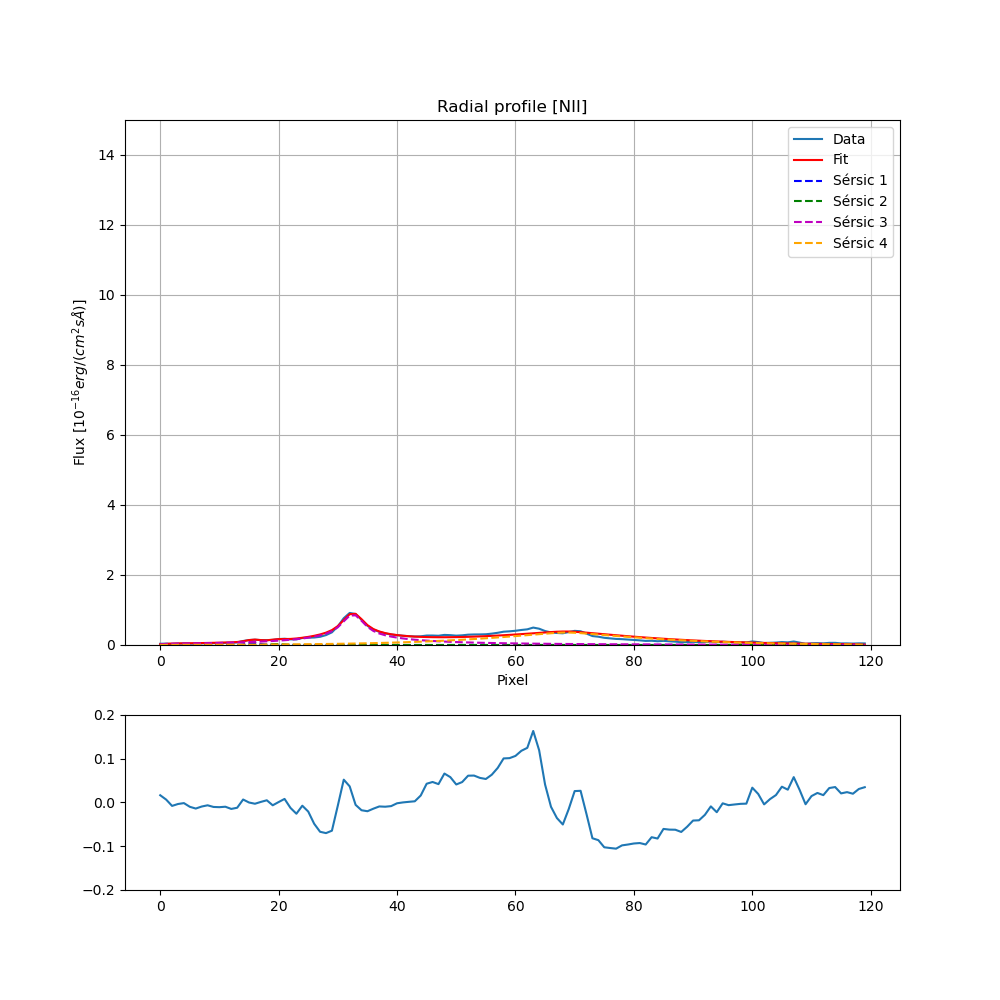

In [87]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [88]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.8129, r_e=0.0317, n=0.7805, x_0=15.6962
Sérsic 2: I_e=0.0518, r_e=0.0512, n=1.9805, x_0=19.7886
Sérsic 3: I_e=0.0174, r_e=49.2129, n=2.5003, x_0=32.8225
Sérsic 4: I_e=0.0618, r_e=30.7640, n=1.0691, x_0=68.6303
[5.85669010e+05 6.38839290e+03 1.67852850e+06 5.91511726e+02
 7.18043020e+04 1.63154898e+04 9.80234152e+05 9.86683655e+01
 2.65931825e-02 5.66331983e+01 1.31682585e+00 3.82395641e-03
 1.67506296e-02 7.74151049e+00 1.87886861e-01 7.88623649e-01]
8.887130392518317


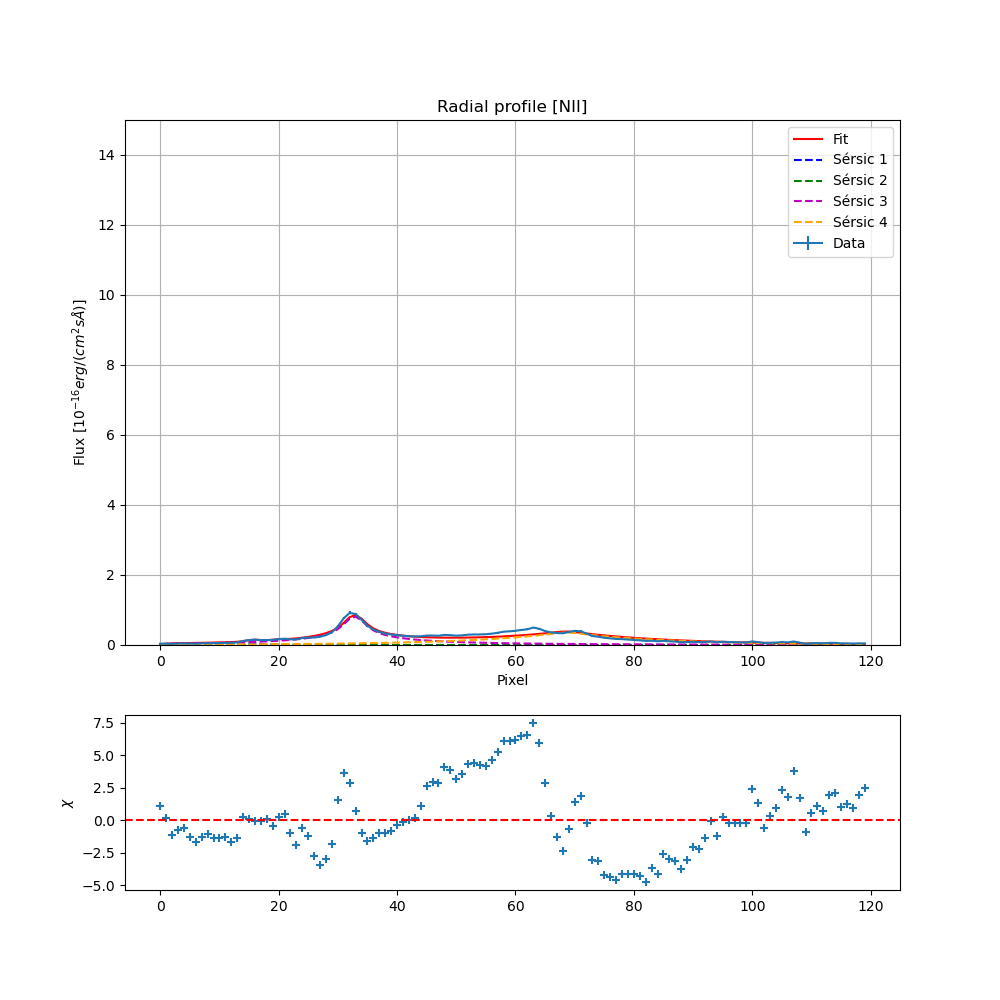

In [89]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

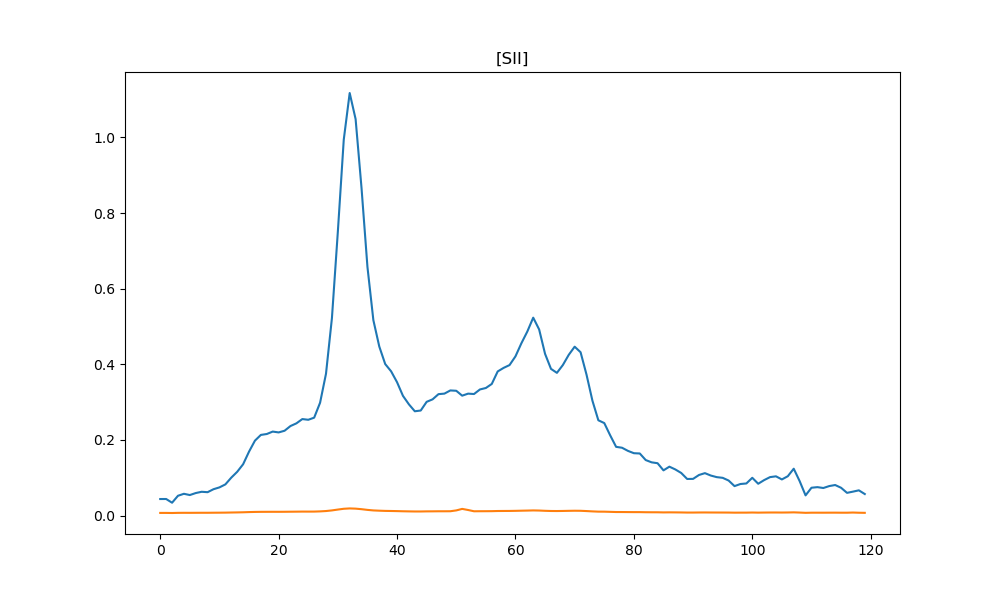

In [90]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 120, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [91]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1222.7018529409816
differential_evolution step 2: f(x)= 710.5051427743879
differential_evolution step 3: f(x)= 152.09241456981255
differential_evolution step 4: f(x)= 152.09241456981255
differential_evolution step 5: f(x)= 152.09241456981255
differential_evolution step 6: f(x)= 103.36844269718918
differential_evolution step 7: f(x)= 16.1334123571608
differential_evolution step 8: f(x)= 16.1334123571608
differential_evolution step 9: f(x)= 16.1334123571608
differential_evolution step 10: f(x)= 16.1334123571608
differential_evolution step 11: f(x)= 16.1334123571608
differential_evolution step 12: f(x)= 16.1334123571608
differential_evolution step 13: f(x)= 16.1334123571608
differential_evolution step 14: f(x)= 16.1334123571608
differential_evolution step 15: f(x)= 16.1334123571608
differential_evolution step 16: f(x)= 16.1334123571608
differential_evolution step 17: f(x)= 16.1334123571608
differential_evolution step 18: f(x)= 16.1334123571608
differen

Sérsic 1: I_e=0.0681, r_e=1.5552, n=0.1323, x_0=16.7116
Sérsic 2: I_e=0.1250, r_e=0.1717, n=0.4312, x_0=20.1587
Sérsic 3: I_e=0.0204, r_e=49.9998, n=2.5962, x_0=32.2868
Sérsic 4: I_e=0.0877, r_e=29.0338, n=0.9366, x_0=68.6303


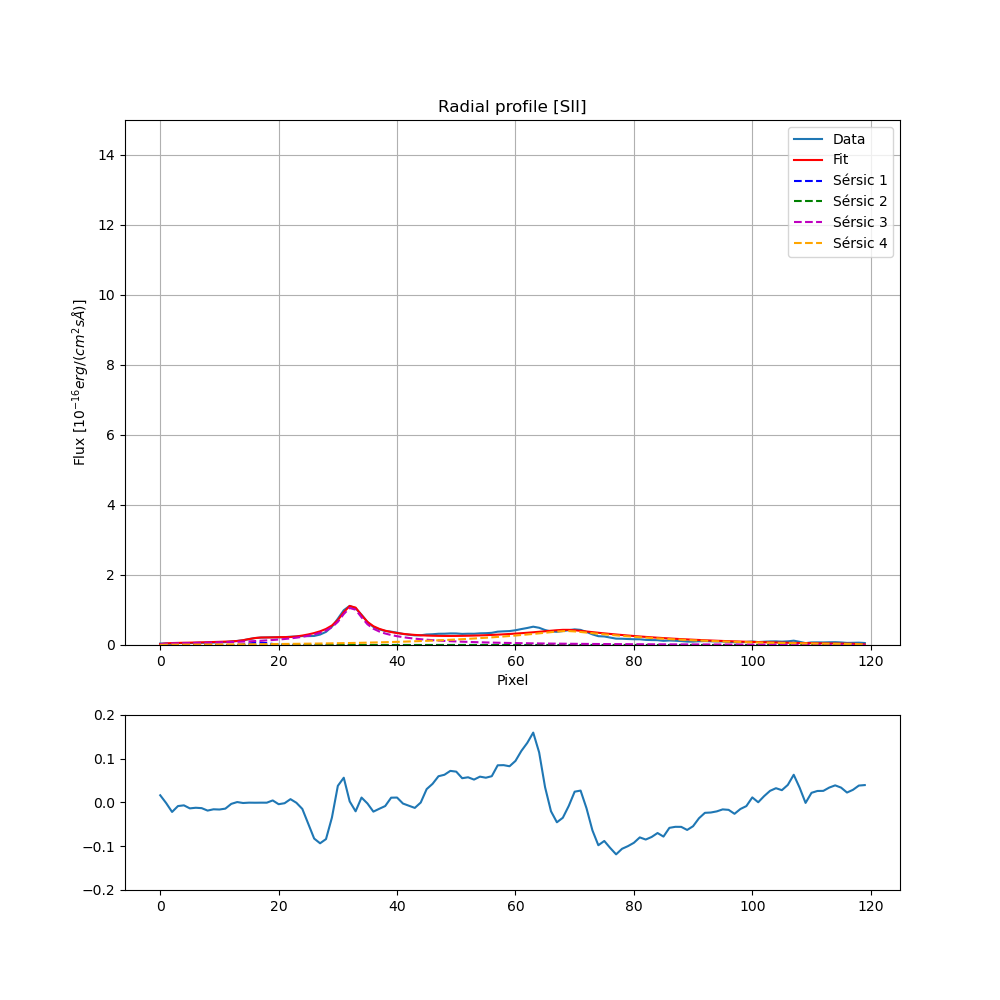

In [92]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [93]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0617, r_e=1.5065, n=0.1137, x_0=16.7128
Sérsic 2: I_e=0.0336, r_e=1.0217, n=0.1514, x_0=19.9965
Sérsic 3: I_e=0.0206, r_e=49.3871, n=2.5470, x_0=32.5844
Sérsic 4: I_e=0.0491, r_e=41.4465, n=1.2652, x_0=68.6303
[1.41695609e+00 8.82115493e+01 1.47701623e+01 3.44661944e+01
 3.48489154e-01 1.57367473e+02 8.45151888e+01 6.55502762e+01
 2.98915526e-02 5.39065263e+01 1.25609055e+00 3.49863515e-03
 1.57849692e-02 1.27489182e+01 2.19950599e-01 6.85705958e-01]
8.710734552509566


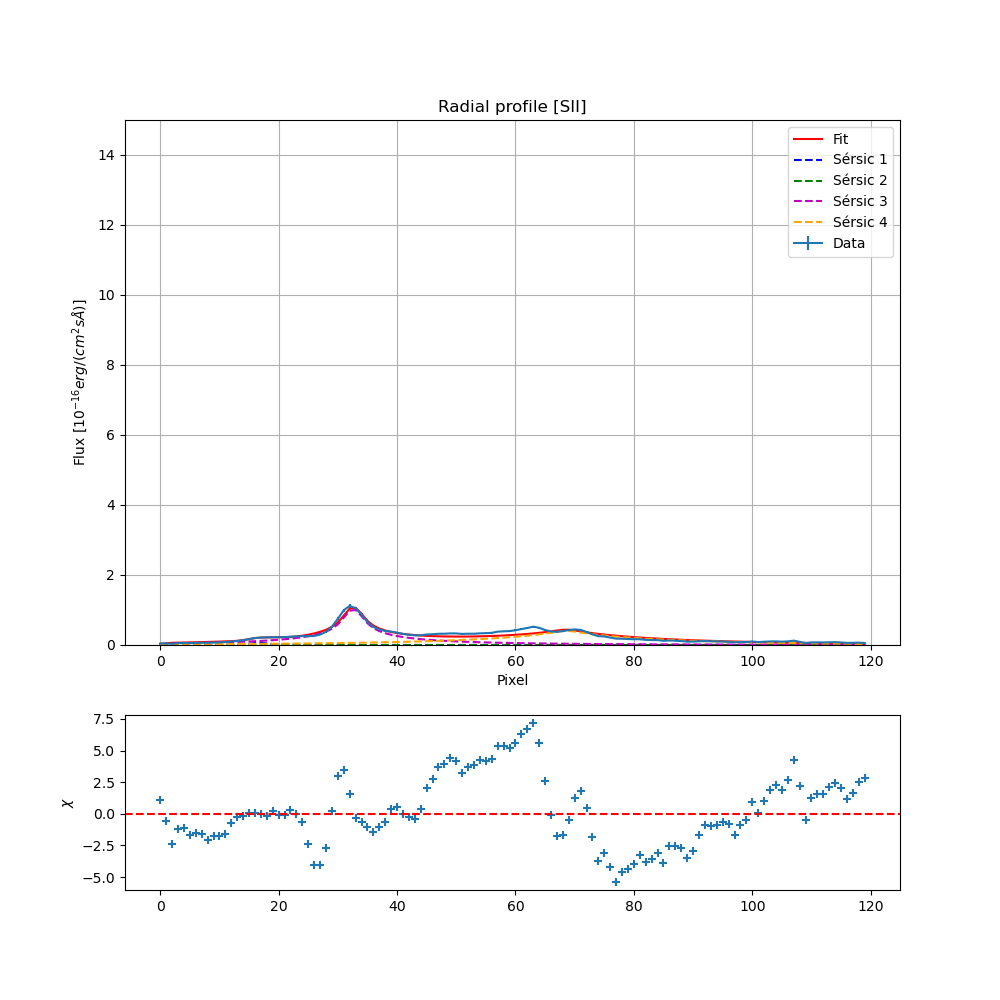

In [94]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

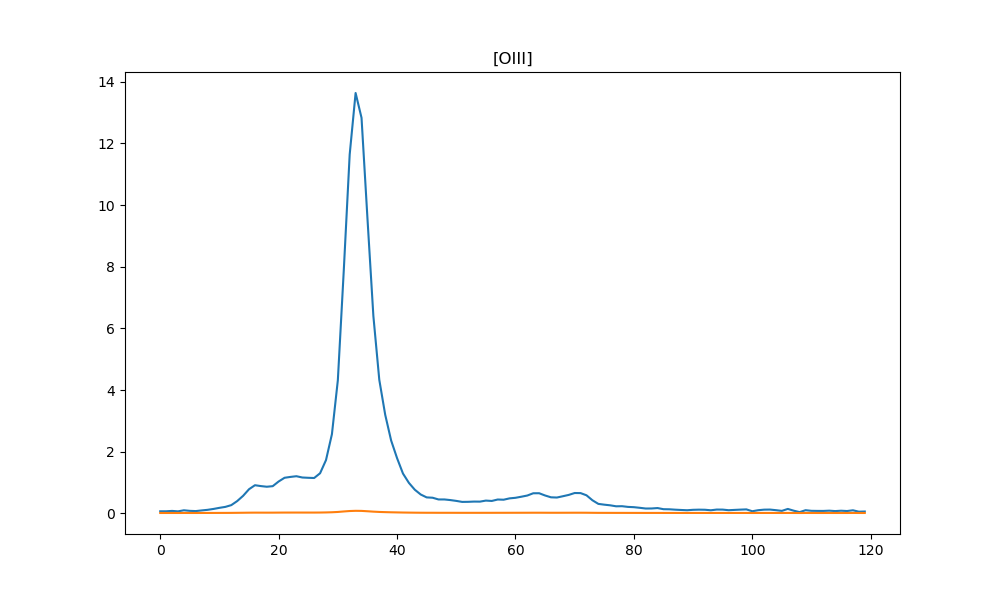

In [69]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [75]:
# Bounds:
bounds =[
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 5),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 5),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 406.3901520529392
differential_evolution step 2: f(x)= 406.3901520529392
differential_evolution step 3: f(x)= 406.3901520529392
differential_evolution step 4: f(x)= 103.37800420267507
differential_evolution step 5: f(x)= 103.37800420267507
differential_evolution step 6: f(x)= 103.37800420267507
differential_evolution step 7: f(x)= 103.37800420267507
differential_evolution step 8: f(x)= 45.83931286706546
differential_evolution step 9: f(x)= 45.83931286706546
differential_evolution step 10: f(x)= 45.83931286706546
differential_evolution step 11: f(x)= 30.202704883470222
differential_evolution step 12: f(x)= 30.202704883470222
differential_evolution step 13: f(x)= 30.202704883470222
differential_evolution step 14: f(x)= 30.202704883470222
differential_evolution step 15: f(x)= 28.98227977107232
differential_evolution step 16: f(x)= 27.081423385111393
differential_evolution step 17: f(x)= 27.081423385111393
differential_evolution step 18: f(x)= 27.081423

Sérsic 1: I_e=0.3437, r_e=1.2154, n=0.6874, x_0=14.7806
Sérsic 2: I_e=0.6040, r_e=3.3346, n=0.1059, x_0=20.1556
Sérsic 3: I_e=1.4019, r_e=6.4078, n=1.7939, x_0=33.2849
Sérsic 4: I_e=0.0749, r_e=39.4116, n=1.2860, x_0=68.6317


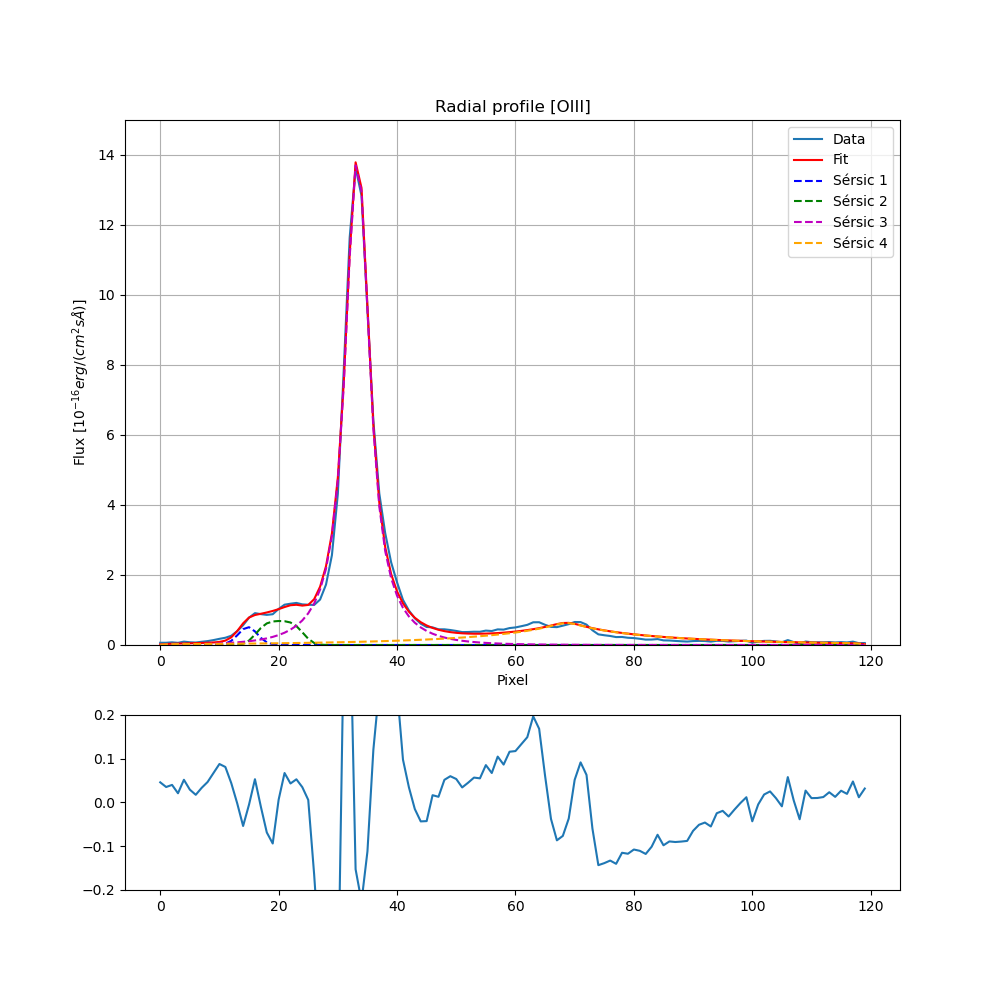

In [76]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [77]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2350, r_e=2.2070, n=0.9565, x_0=15.9400
Sérsic 2: I_e=0.5682, r_e=2.2131, n=0.1000, x_0=21.4228
Sérsic 3: I_e=0.4941, r_e=11.6592, n=2.7463, x_0=33.4626
Sérsic 4: I_e=0.0379, r_e=49.9835, n=1.6878, x_0=68.6303
[3.11979509e-01 1.13102630e+00 1.19805982e+00 7.19944071e-01
 3.28051552e+00 1.53994758e+01 2.03900332e+00 6.98202542e-01
 1.36627872e-01 1.91546120e+00 2.75496879e-01 8.64079201e-02
 1.44768583e-02 1.50691453e+01 2.60831654e-01 4.49047303e-01]
7.759957485546715


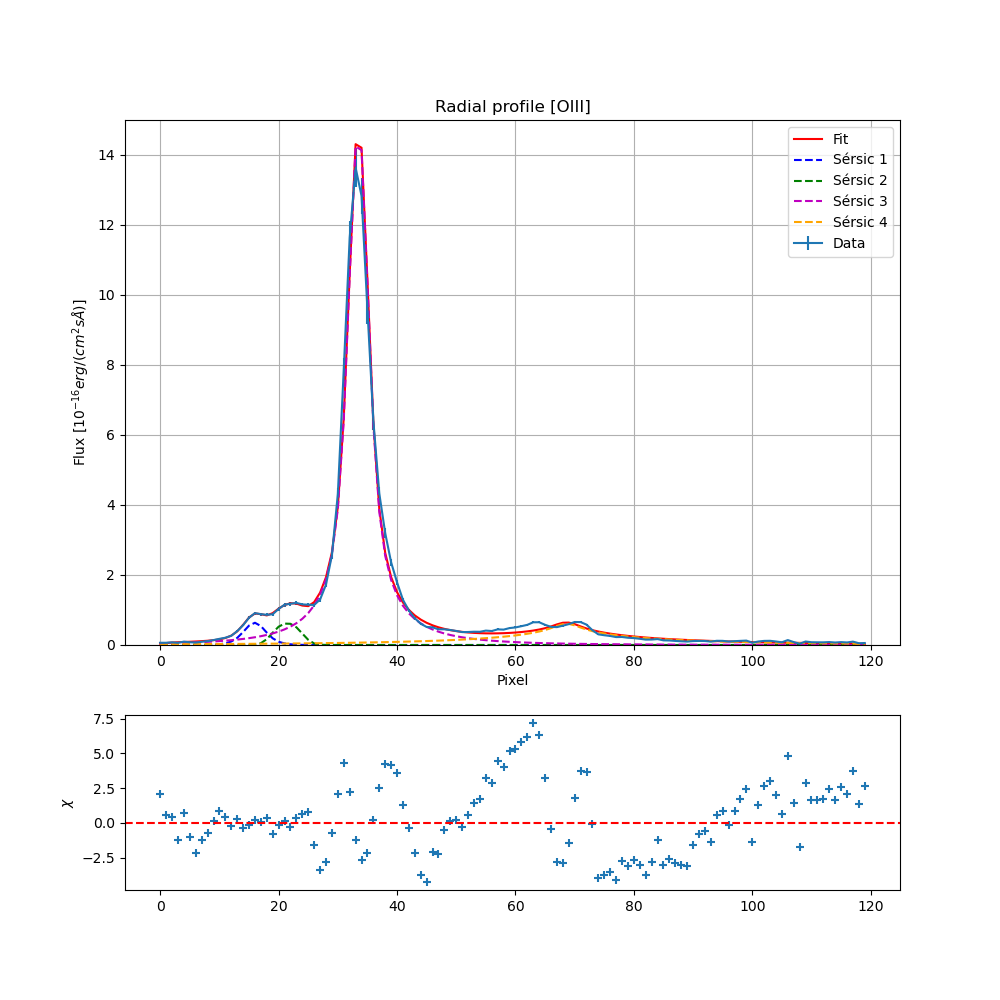

In [78]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [95]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

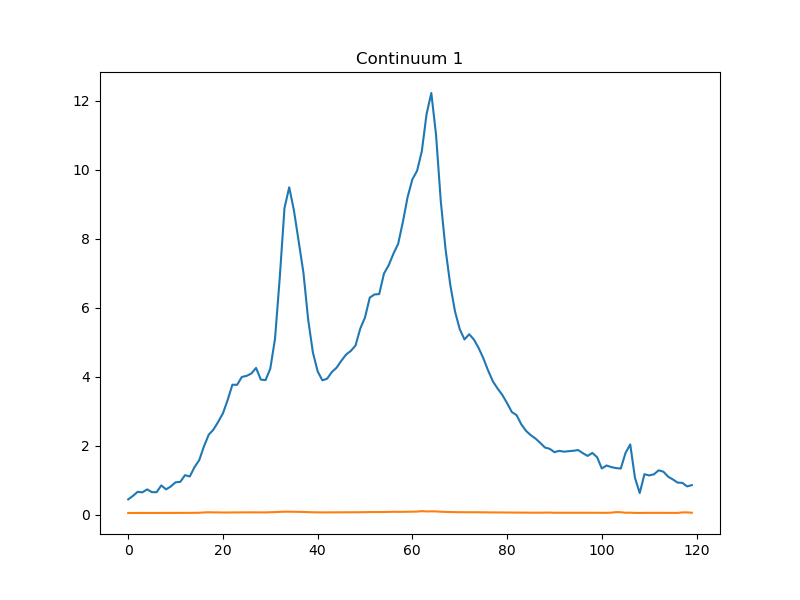

In [111]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [112]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 8993.192486272728
differential_evolution step 2: f(x)= 8993.192486272728
differential_evolution step 3: f(x)= 1063.633711779146
differential_evolution step 4: f(x)= 1058.2594930520663
differential_evolution step 5: f(x)= 1058.2594930520663
differential_evolution step 6: f(x)= 1058.2594930520663
differential_evolution step 7: f(x)= 1058.2594930520663
differential_evolution step 8: f(x)= 944.6524393459322
differential_evolution step 9: f(x)= 944.6524393459322
differential_evolution step 10: f(x)= 494.77777878916436
differential_evolution step 11: f(x)= 494.77777878916436
differential_evolution step 12: f(x)= 494.77777878916436
differential_evolution step 13: f(x)= 494.77777878916436
differential_evolution step 14: f(x)= 494.77777878916436
differential_evolution step 15: f(x)= 486.31927449329623
differential_evolution step 16: f(x)= 486.31927449329623
differential_evolution step 17: f(x)= 486.31927449329623
differential_evolution step 18: f(x)= 378.490

In [113]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=0.0000, r_e=0.2293, n=0.7492, x_0=15.5001
Sérsic 2: I_e=0.4734, r_e=2.9352, n=0.1001, x_0=21.0000
Sérsic 3: I_e=0.5501, r_e=49.9996, n=1.6421, x_0=34.5781
Sérsic 4: I_e=3.6063, r_e=15.0231, n=0.4378, x_0=69.0000


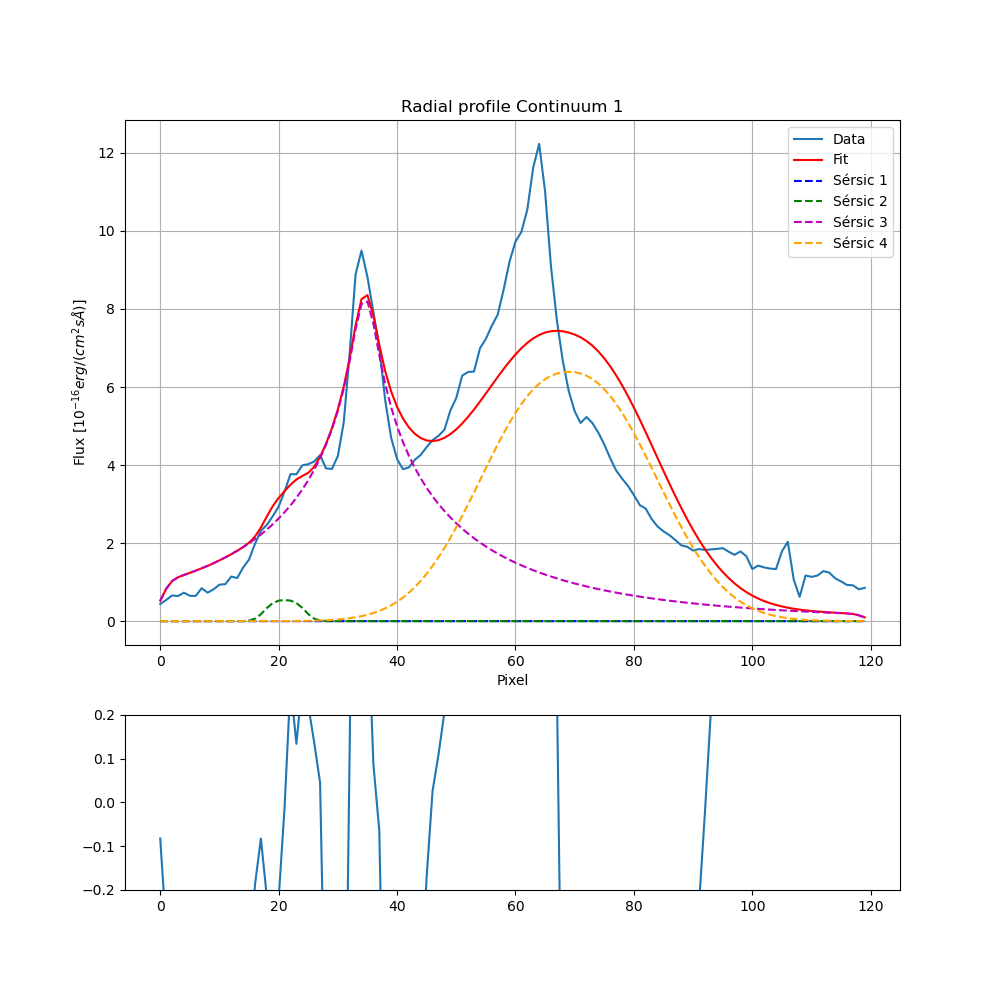

In [114]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [115]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=5.4214, r_e=0.0000, n=0.5864, x_0=15.0097
Sérsic 2: I_e=0.8470, r_e=4.0786, n=0.1000, x_0=21.0000
Sérsic 3: I_e=0.8901, r_e=19.8141, n=1.2248, x_0=34.8757
Sérsic 4: I_e=0.8626, r_e=43.8118, n=1.2073, x_0=69.0000
[0.00000000e+00 3.64052250e-14 6.32568430e-14 4.88256827e-14
 2.56264677e+00 1.43781514e+01 1.01991007e+00 1.52678393e+00
 4.23840219e-01 6.11449547e+00 3.65761887e-01 7.43621558e-01
 2.53049696e-01 9.44079949e+00 2.03936296e-01 1.29310960e+00]
34.04828690597301


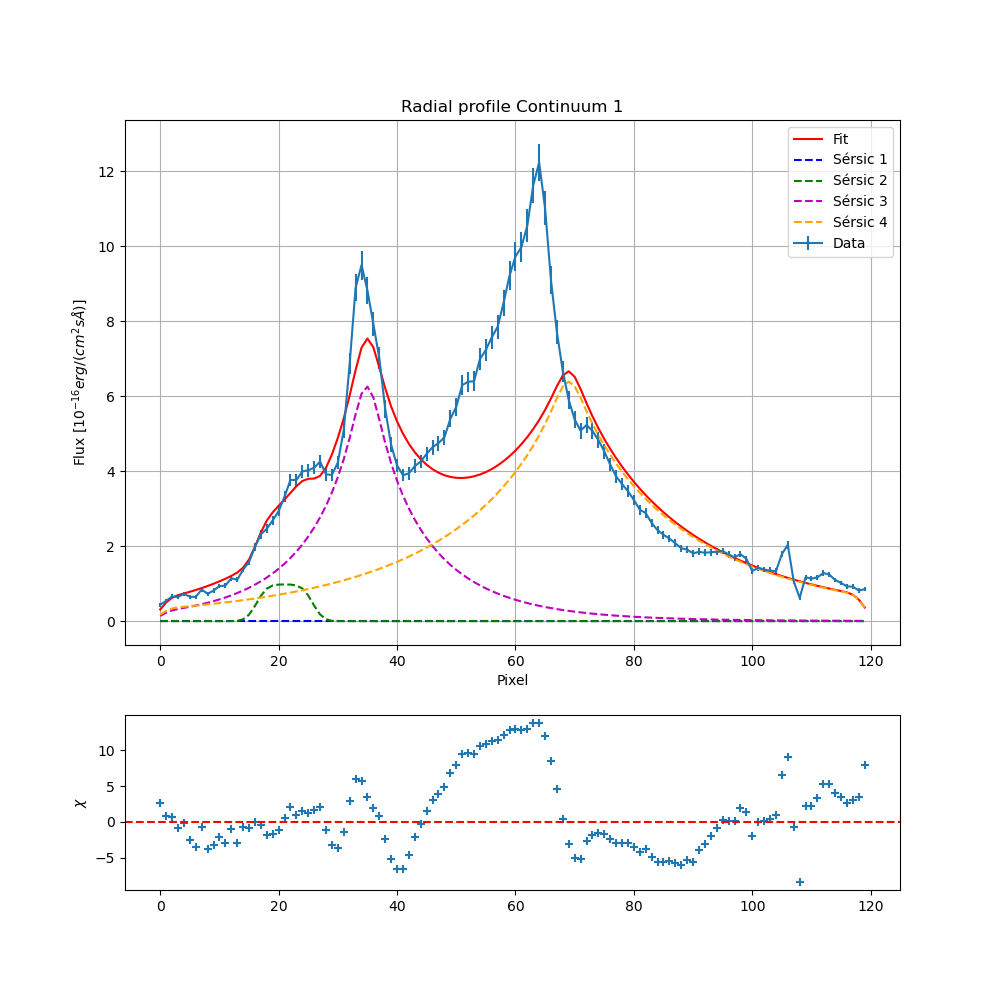

In [116]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

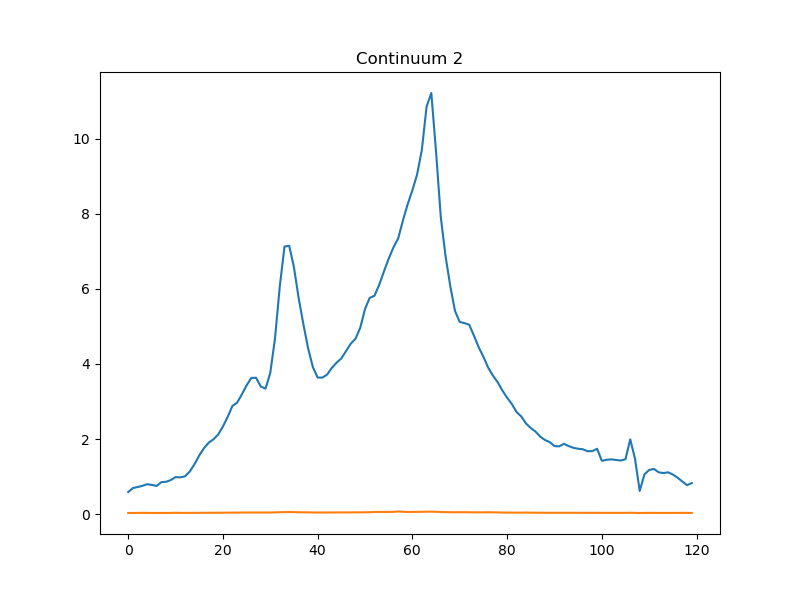

In [117]:
mask_continuum_2 = (wv > 5100)*(wv < 5400)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [118]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 6638.488782336902
differential_evolution step 2: f(x)= 6638.488782336902
differential_evolution step 3: f(x)= 4529.676085085655
differential_evolution step 4: f(x)= 4529.676085085655
differential_evolution step 5: f(x)= 3333.663206412143
differential_evolution step 6: f(x)= 1527.3883593650498
differential_evolution step 7: f(x)= 1527.3883593650498
differential_evolution step 8: f(x)= 1138.6791809055633
differential_evolution step 9: f(x)= 1138.6791809055633
differential_evolution step 10: f(x)= 1138.6791809055633
differential_evolution step 11: f(x)= 983.7028100087587
differential_evolution step 12: f(x)= 983.7028100087587
differential_evolution step 13: f(x)= 609.0525876352781
differential_evolution step 14: f(x)= 609.0525876352781
differential_evolution step 15: f(x)= 609.0525876352781
differential_evolution step 16: f(x)= 488.86280223642484
differential_evolution step 17: f(x)= 488.86280223642484
differential_evolution step 18: f(x)= 488.86280223

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\3384502307.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=8.6284, r_e=0.0001, n=5.7726, x_0=15.5197
Sérsic 2: I_e=1.7448, r_e=0.0001, n=4.5342, x_0=20.1078
Sérsic 3: I_e=0.5793, r_e=49.9998, n=1.3853, x_0=34.3698
Sérsic 4: I_e=2.8940, r_e=16.8122, n=0.5045, x_0=69.0000
Chi quadro minimo: 177.91232602592044
True


Sérsic 1: I_e=8.6284, r_e=0.0001, n=5.7726, x_0=15.5197
Sérsic 2: I_e=1.7448, r_e=0.0001, n=4.5342, x_0=20.1078
Sérsic 3: I_e=0.5793, r_e=49.9998, n=1.3853, x_0=34.3698
Sérsic 4: I_e=2.8940, r_e=16.8122, n=0.5045, x_0=69.0000


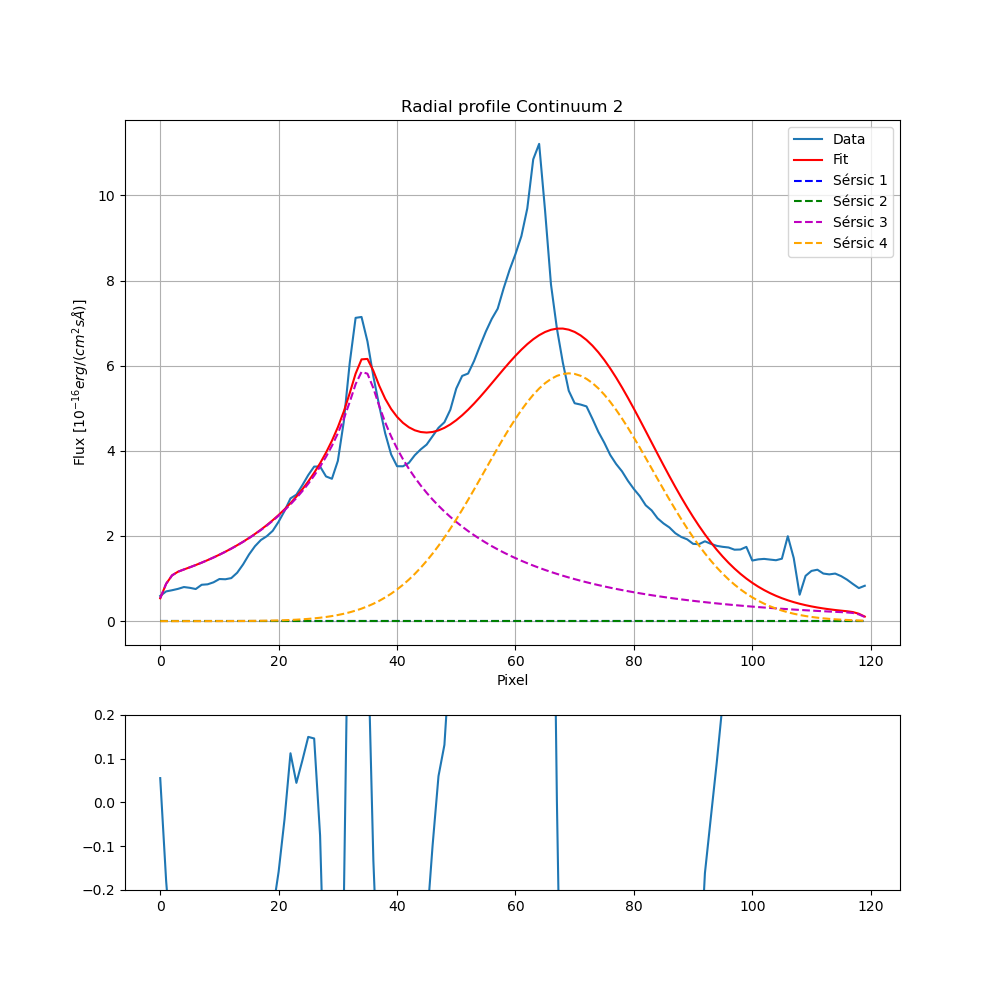

In [119]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [120]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=7.9220, r_e=0.0000, n=4.0149, x_0=15.9235
Sérsic 2: I_e=0.0061, r_e=0.0791, n=9.0832, x_0=20.4421
Sérsic 3: I_e=1.3071, r_e=17.1166, n=0.6628, x_0=35.0000
Sérsic 4: I_e=0.7438, r_e=50.0000, n=1.2575, x_0=69.0000
[0.00000000e+00 5.39191512e-03 1.06642526e-02 1.50773747e-02
 3.73356157e+03 1.52027824e+04 4.30680208e+06 3.82353155e+02
 3.86609961e-01 2.58176470e+00 2.07633775e-01 1.52505315e+00
 2.39323174e-01 1.14620223e+01 2.15448896e-01 1.31892555e+00]
31.774549866736038


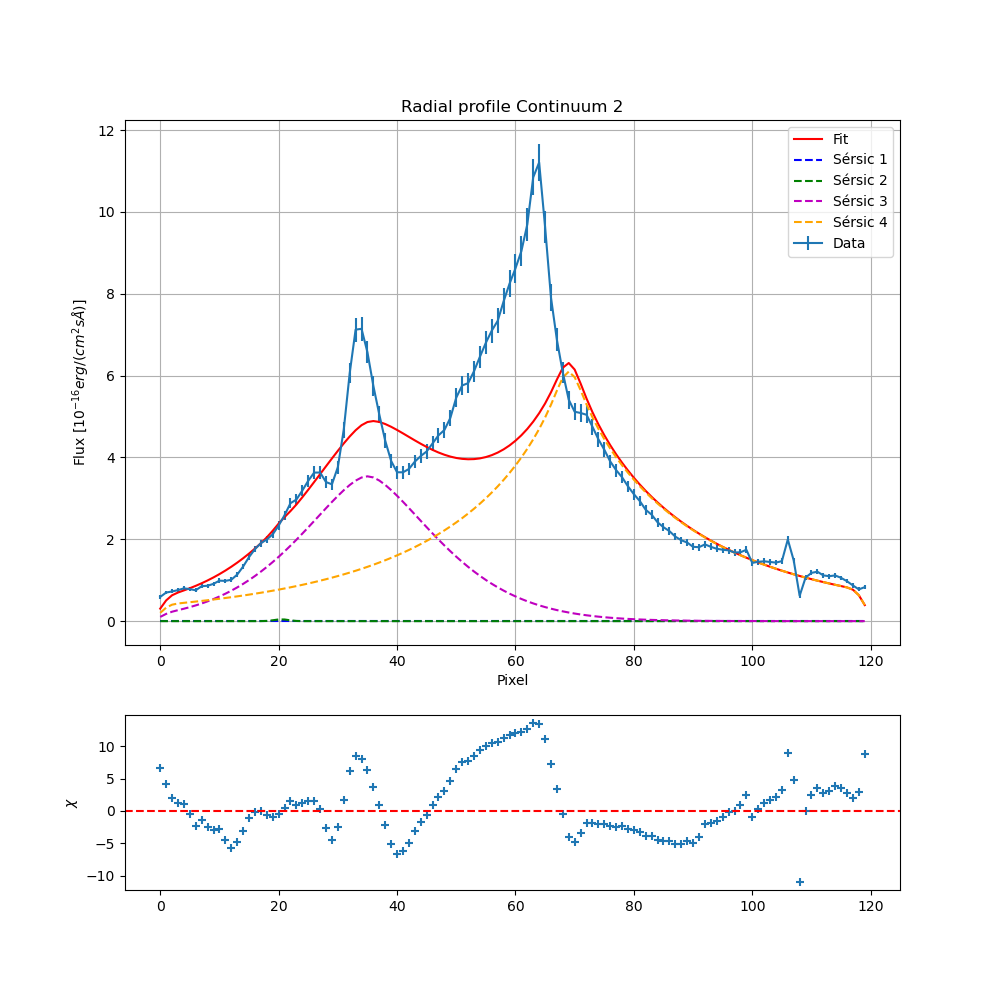

In [121]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

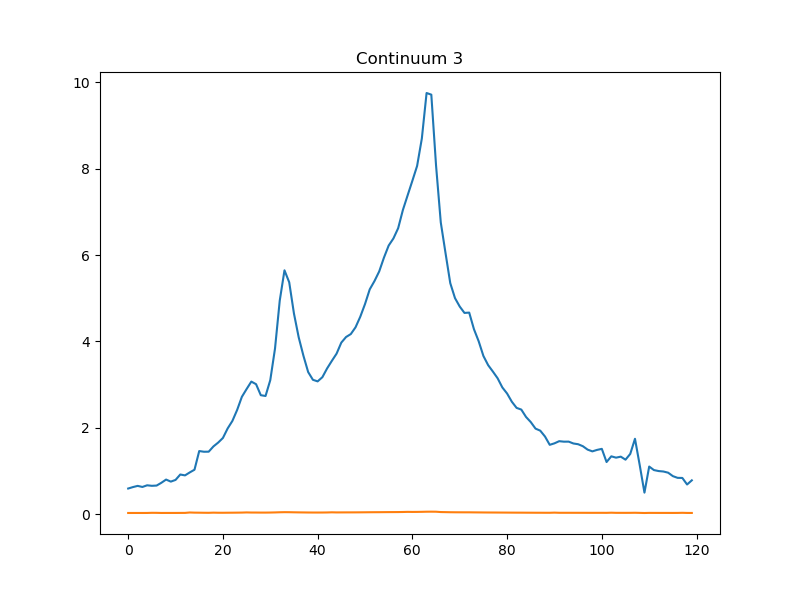

In [122]:
mask_continuum_3 = (wv > 5910)*(wv < 6210)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [123]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1929.4526400412396
differential_evolution step 2: f(x)= 1929.4526400412396
differential_evolution step 3: f(x)= 1725.6424180150188
differential_evolution step 4: f(x)= 1725.6424180150188
differential_evolution step 5: f(x)= 1725.6424180150188
differential_evolution step 6: f(x)= 1405.212479679185
differential_evolution step 7: f(x)= 1405.212479679185
differential_evolution step 8: f(x)= 1405.212479679185
differential_evolution step 9: f(x)= 1405.212479679185
differential_evolution step 10: f(x)= 989.5200309219196
differential_evolution step 11: f(x)= 989.5200309219196
differential_evolution step 12: f(x)= 989.5200309219196
differential_evolution step 13: f(x)= 730.7939269513006
differential_evolution step 14: f(x)= 730.7939269513006
differential_evolution step 15: f(x)= 730.7939269513006
differential_evolution step 16: f(x)= 730.7939269513006
differential_evolution step 17: f(x)= 404.5147345098022
differential_evolution step 18: f(x)= 404.5147345098

Sérsic 1: I_e=0.0008, r_e=0.0005, n=6.4781, x_0=15.4571
Sérsic 2: I_e=0.0013, r_e=0.0003, n=2.4832, x_0=20.0310
Sérsic 3: I_e=2.0530, r_e=26.6451, n=0.1000, x_0=35.0000
Sérsic 4: I_e=1.8599, r_e=23.9157, n=0.6963, x_0=69.0000


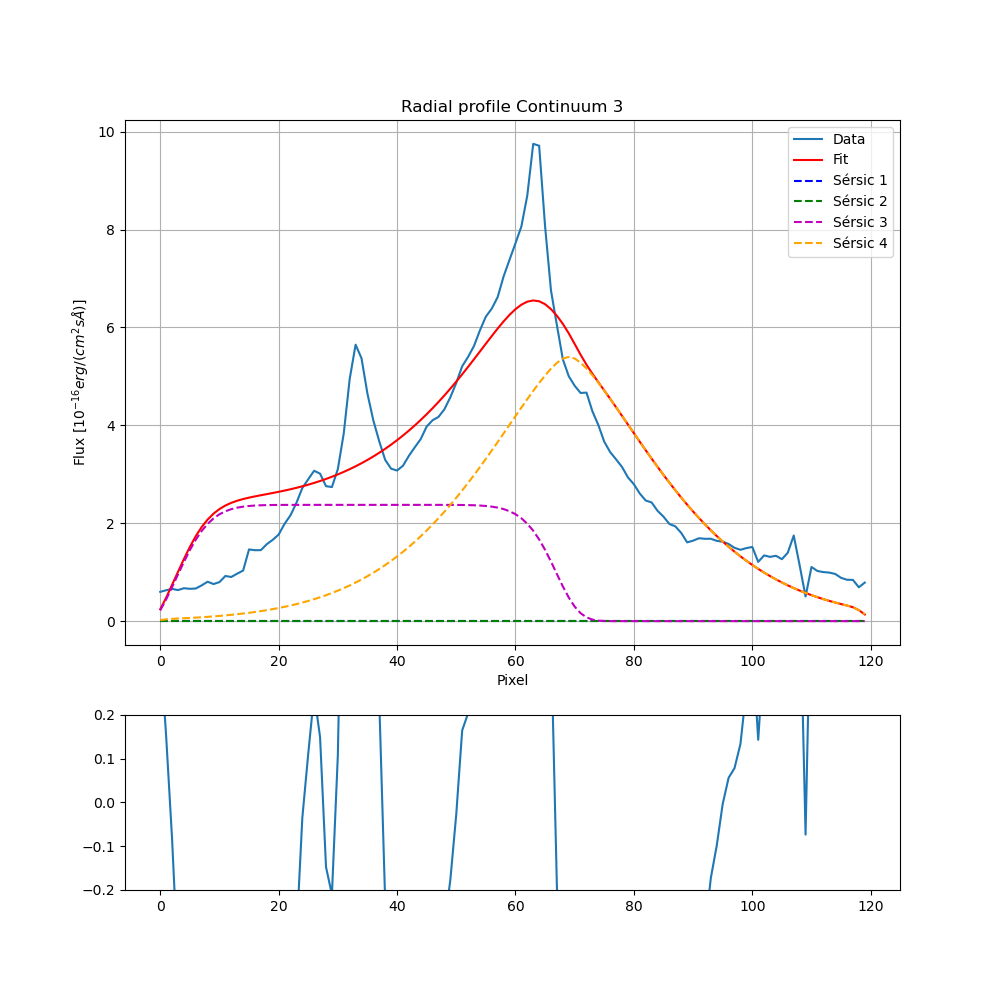

In [124]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [125]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0026, r_e=0.0008, n=19.6519, x_0=17.1895
Sérsic 2: I_e=-0.0016, r_e=0.0002, n=-3.7311, x_0=20.1287
Sérsic 3: I_e=2.0530, r_e=26.6451, n=0.1000, x_0=35.0000
Sérsic 4: I_e=1.8599, r_e=23.9157, n=0.6963, x_0=69.0000
[1.36197897e+04 4.10122882e+03 9.47583779e+07 7.64227318e+04
 3.68048925e+03 6.01938322e+02 1.47510361e+06 7.67542176e+05
 8.61119635e-01 6.80244088e+00 6.13018931e-02 4.47481135e+00
 7.51633649e-01 1.05473359e+01 3.64316659e-01 3.29548582e+00]
124.04891634849194


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\3384502307.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\3384502307.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


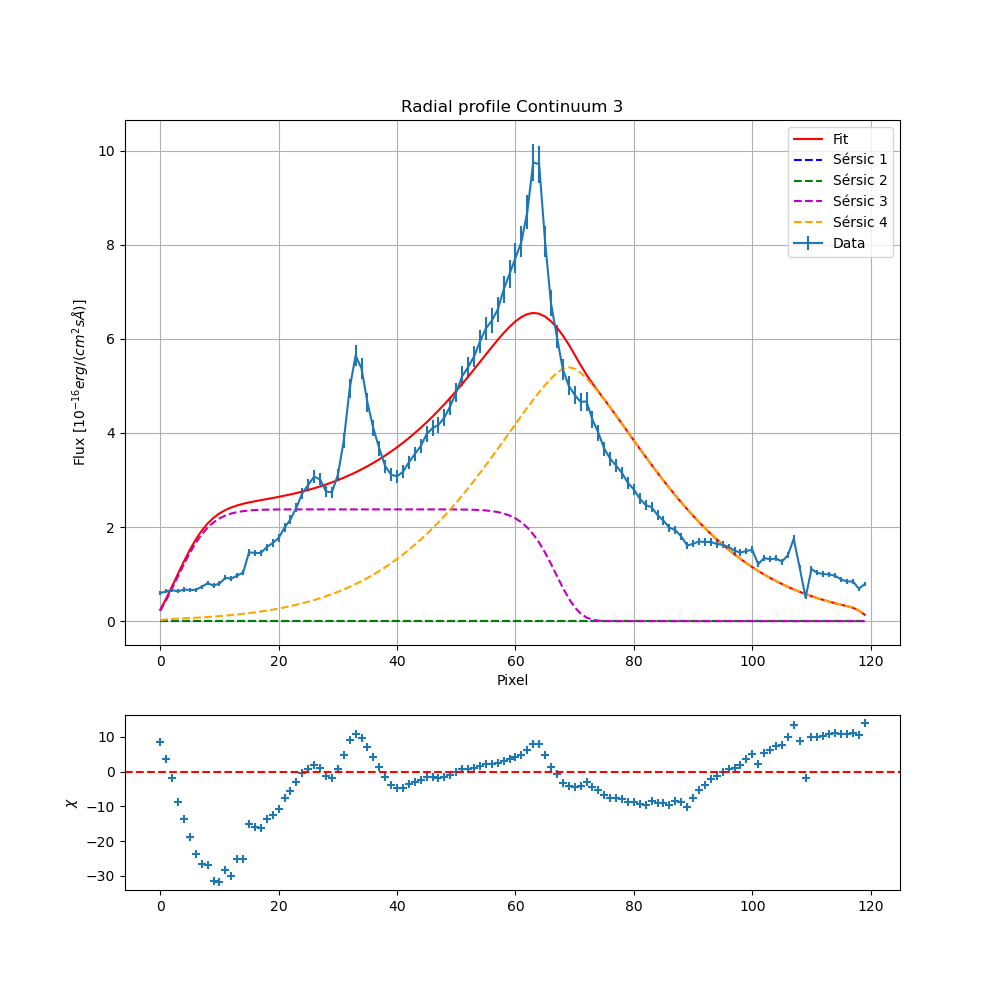

In [126]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [127]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

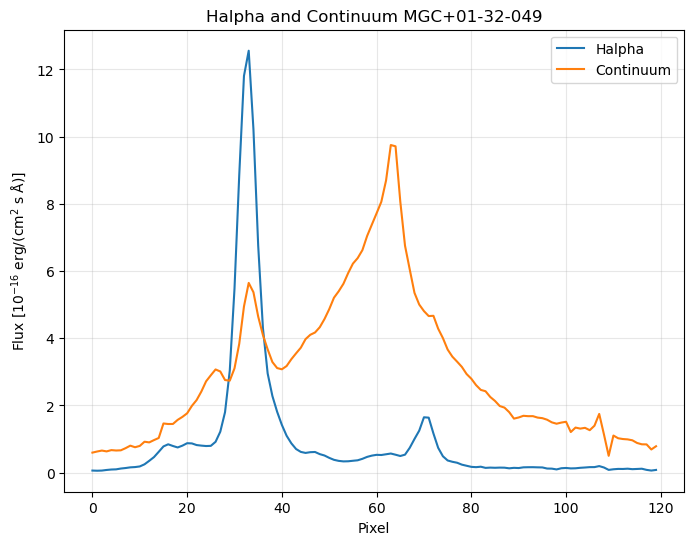

In [12]:
mask_continuum_3 = (wv > 5910)*(wv < 6210)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum MGC+01-32-049')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_MGC+01-32-049')